### Global Explanation

Answers:

> Which features are important overall?

Example:

Chest Pain          ████████████

Old Peak            █████████

Thalach             ████████

Age                 ██████

Cholesterol         ███

### Local Explanation

Answers:

> Why THIS patient?

Patient A

Prediction = Heart Disease

Reasons

Chest Pain = High Risk

Old Peak = High Risk

Age = High Risk

Heart Rate = Protective

Patient B could have completely different reasons.

### Feature Importance (Tree Models)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import joblib


df = pd.read_csv("../data/raw/heart_disease_data.csv")

X = df.drop("target",axis=1)
y = df["target"]

X_train, X_test, Y_train, Y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)


# Load the model back into memory
best_model = joblib.load('../models/best_model.pkl')

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.named_steps["model"].feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,cp,0.199683
12,thal,0.134751
11,ca,0.120650
9,oldpeak,0.118763
7,thalach,0.109700
8,exang,0.108375
10,slope,0.091029
0,age,0.032600
4,chol,0.031676
1,sex,0.029946


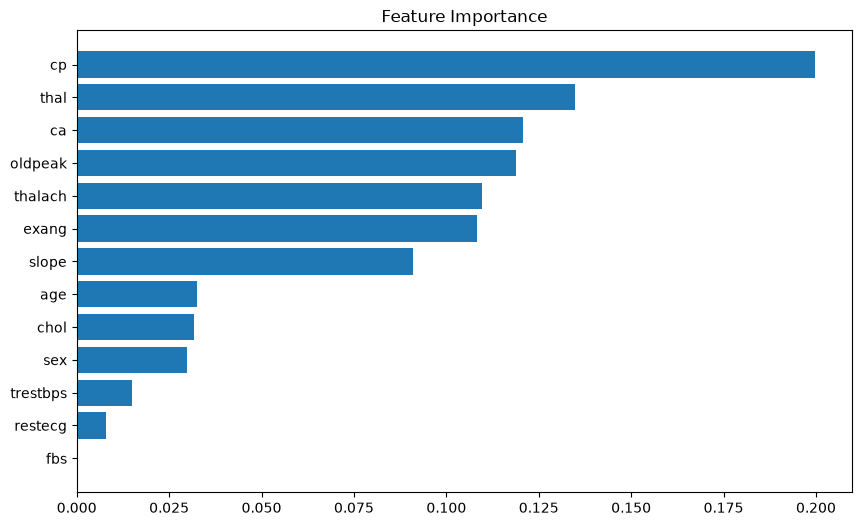

In [2]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")

plt.show()

### Logistic Regression Coefficients

In [4]:
log_model = joblib.load('../models/log_model.pkl')

coefficients = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": log_model.coef_[0]

})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
2,cp,0.916865
7,thalach,0.525418
10,slope,0.452345
6,restecg,0.401378
0,age,0.018858
5,fbs,-0.159022
3,trestbps,-0.201311
4,chol,-0.413767
11,ca,-0.554480
9,oldpeak,-0.621343


### SHAP (SHapley Additive exPlanations)

In [27]:
import shap


explainer = shap.TreeExplainer(
    best_model.named_steps["model"]
)

explainer = shap.TreeExplainer(best_model.named_steps["model"])

shap_values = explainer.shap_values(X_test)



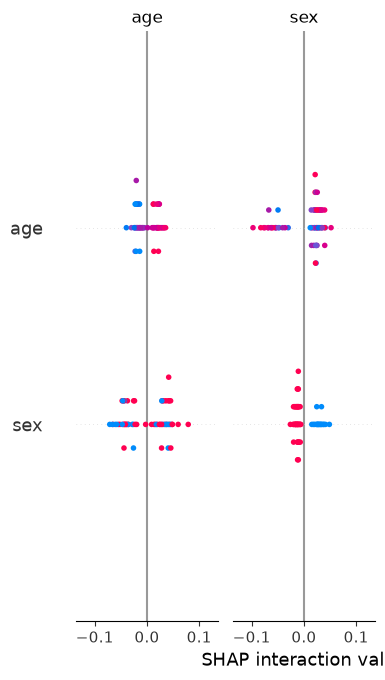

In [29]:
shap.summary_plot(
    shap_values,
    X_test
)

### Explain One Patient

In [28]:
patient = X_test.iloc[[5]]

positive_class_shap = shap_values[:, :, 1]
patient_shap = positive_class_shap[5]
base_val = explainer.expected_value[1]

shap.plots.force(base_val, patient_shap, patient.iloc[0])


### Waterfall Plot

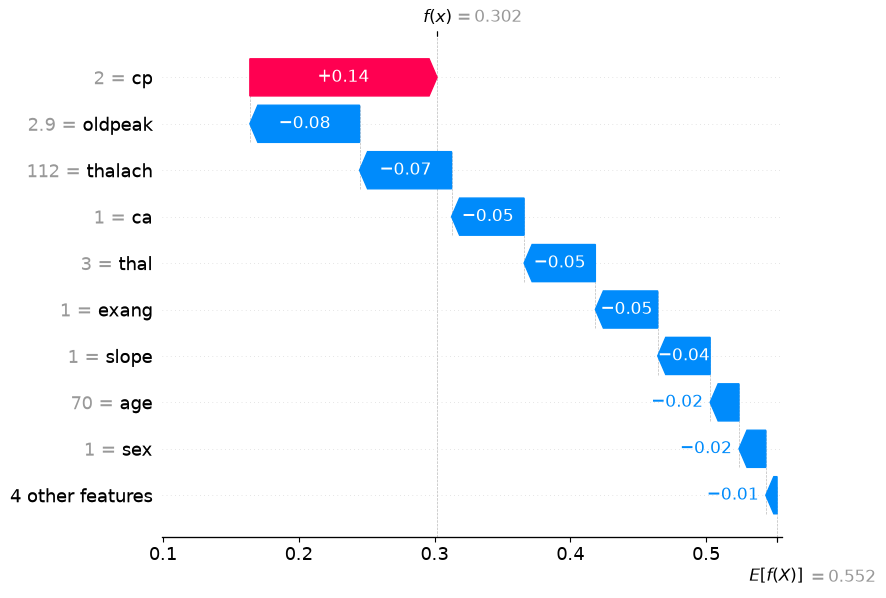

In [31]:
exp = shap.Explanation(
    values=patient_shap,
    base_values=base_val,
    data=patient.iloc[0].to_numpy(),
    feature_names=list(X.columns)
)
shap.plots.waterfall(exp)


In [32]:
sample = X_test.iloc[[0]]

prediction = best_model.predict(sample)
probability = best_model.predict_proba(sample)
print(prediction)
print(probability)

[0]
[[0.78699823 0.21300177]]
